<a href="https://colab.research.google.com/github/MdAshraf123/ML/blob/main/scorePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import random

students=['x1','x2','x3','x4','x5','x6','x7','x8','x9','x10']
subjects=['M1','Chemistry','EVS','English','PPS']
days=150
date=datetime(2025,2,12)
data1=[]
for day in range(days):
  today=date+timedelta(days=day)
  for student in students:
    for sub in subjects:
      stdyHrs=round(random.uniform(0,3))
      assi=0
      # assi=np.NaN
      # assi=random.randint(10,25)
      # atten=random.choice([1,0], weights=[0.7,0.3])[0]
      atten= random.choices([0, 1], weights=[0.3, 0.7])[0]
      data1.append([today,student,sub,stdyHrs,assi,atten])

df=pd.DataFrame(data=data1,columns=['date','sid','subject','study_hours','assignmet_marks','attendance'])
df.to_csv("student_data_1sem.csv", index=False)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv('student_data_1sem.csv')
grouped_data= df.groupby(['sid','subject']).agg({
    'study_hours':'mean',
    'assignmet_marks':'mean',
    'attendance':'mean'
})
grouped_data

study_hours  assignmet_marks  attendance
sid subject                                            
x1  Chemistry     1.686667         0.300000    0.713333
    EVS           1.560000         0.213333    0.653333
    English       1.500000         0.226667    0.693333
    M1            1.500000         0.253333    0.686667
    PPS           1.540000         0.226667    0.720000
x10 Chemistry     1.533333         0.173333    0.686667
    EVS           1.460000         0.213333    0.780000
    English       1.500000         0.273333    0.660000
    M1            1.626667         0.280000    0.713333
    PPS           1.420000         0.220000    0.660000
x2  Chemistry     1.300000         0.160000    0.673333
    EVS           1.473333         0.213333    0.733333
    English       1.580000         0.173333    0.673333
    M1            1.480000         0.146667    0.733333
    PPS           1.546667         0.273333    0.686667
x3  Chemistry     1.566667         0.213333    0.653333
    EVS           1.386667         0.186667    0.733333
    English       1.540000         0.273333    0.693333
    M1            1.426667         0.300000    0.706667
    PPS           1.593333         0.280000    0.713333
x4  Chemistry     1.506667         0.233333    0.600000
    EVS           1.633333         0.173333    0.706667
    English       1.393333         0.193333    0.700000
    M1            1.573333         0.153333    0.726667
    PPS           1.626667         0.200000    0.726667
x5  Chemistry     1.366667         0.253333    0.720000
    EVS           1.366667         0.200000    0.660000
    English       1.500000         0.286667    0.740000
    M1            1.460000         0.260000    0.733333
    PPS           1.553333         0.240000    0.686667
x6  Chemistry     1.620000         0.260000    0.706667
    EVS           1.506667         0.260000    0.673333
    English       1.500000         0.266667    0.760000
    M1            1.686667         0.213333    0.673333
    PPS           1.493333         0.180000    0.706667
x7  Chemistry     1.366667         0.240000    0.693333
    EVS           1.413333         0.226667    0.653333
    English       1.560000         0.186667    0.706667
    M1            1.546667         0.213333    0.720000
    PPS           1.553333         0.326667    0.686667
x8  Chemistry     1.573333         0.166667    0.700000
    EVS           1.513333         0.226667    0.646667
    English       1.480000         0.306667    0.733333
    M1            1.380000         0.273333    0.706667
    PPS           1.493333         0.253333    0.706667
x9  Chemistry     1.566667         0.186667    0.666667
    EVS           1.586667         0.206667    0.740000
    English       1.520000         0.166667    0.666667
    M1            1.393333         0.226667    0.633333
    PPS           1.500000         0.266667    0.646667

In [ ]:
cross= grouped_data.xs('Chemistry',level='subject').reset_index()
cross

,sid,study_hours,assignmet_marks,attendance
0,x1,1.686667,0.300000,0.713333
1,x10,1.533333,0.173333,0.686667
2,x2,1.300000,0.160000,0.673333
3,x3,1.566667,0.213333,0.653333
4,x4,1.506667,0.233333,0.600000
5,x5,1.366667,0.253333,0.720000
6,x6,1.620000,0.260000,0.706667
7,x7,1.366667,0.240000,0.693333
8,x8,1.573333,0.166667,0.700000
9,x9,1.566667,0.186667,0.666667


In [ ]:
final_data=grouped_data.reset_index()
final_data

,sid,subject,study_hours,assignmet_marks,attendance
0,x1,Chemistry,1.686667,0.300000,0.713333
1,x1,EVS,1.560000,0.213333,0.653333
2,x1,English,1.500000,0.226667,0.693333
3,x1,M1,1.500000,0.253333,0.686667
4,x1,PPS,1.540000,0.226667,0.720000
5,x10,Chemistry,1.533333,0.173333,0.686667
6,x10,EVS,1.460000,0.213333,0.780000
7,x10,English,1.500000,0.273333,0.660000
8,x10,M1,1.626667,0.280000,0.713333
9,x10,PPS,1.420000,0.220000,0.660000


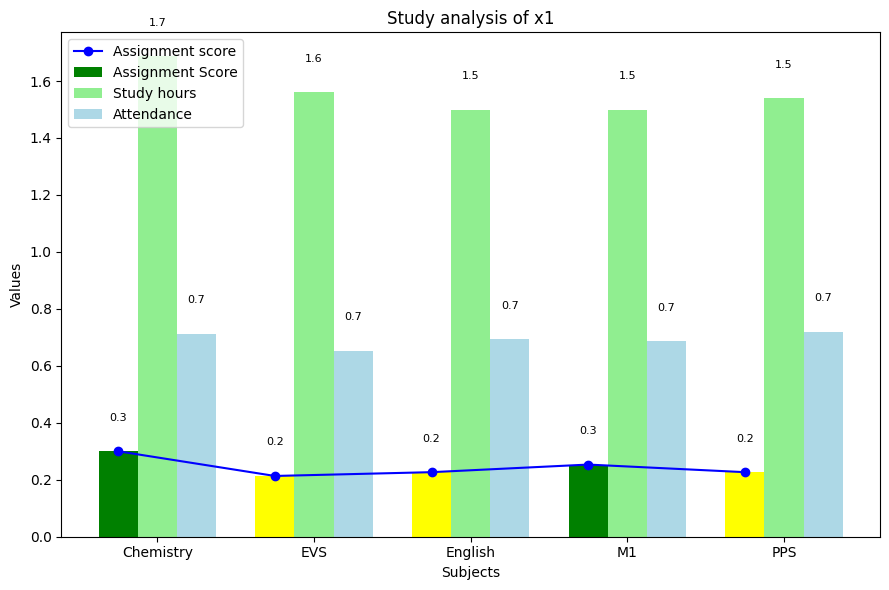

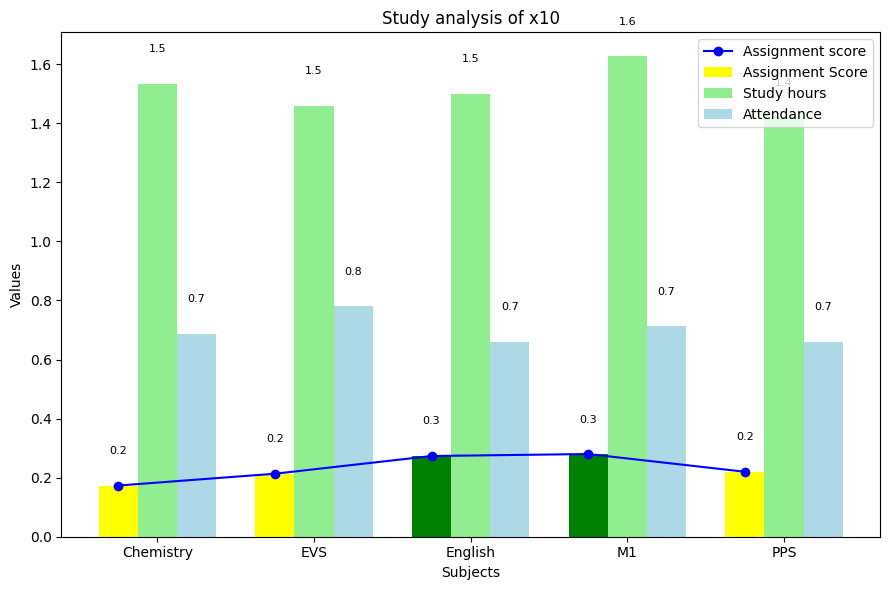

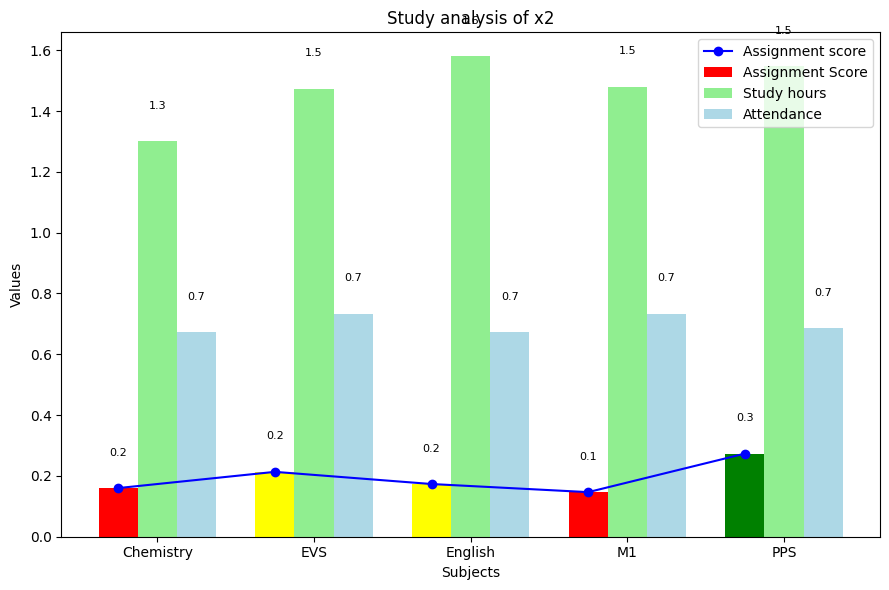

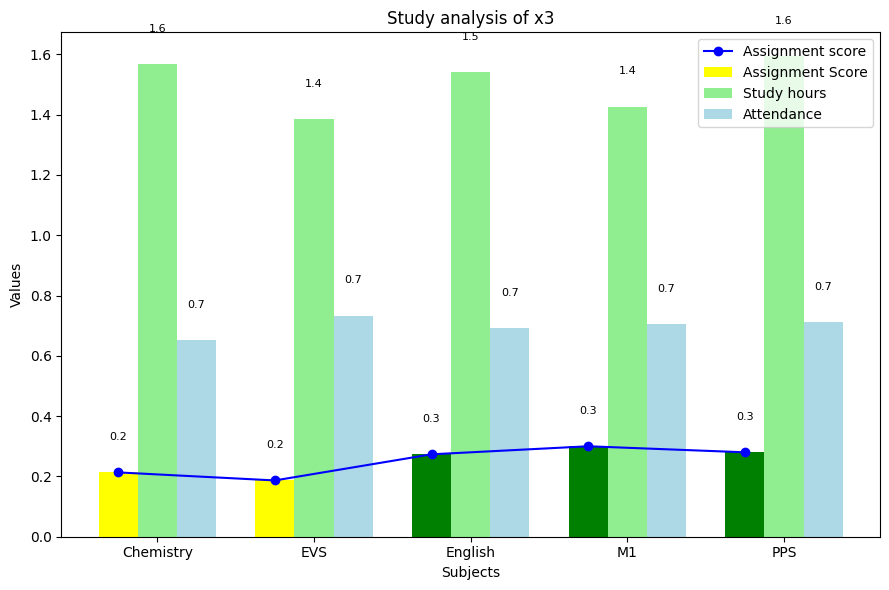

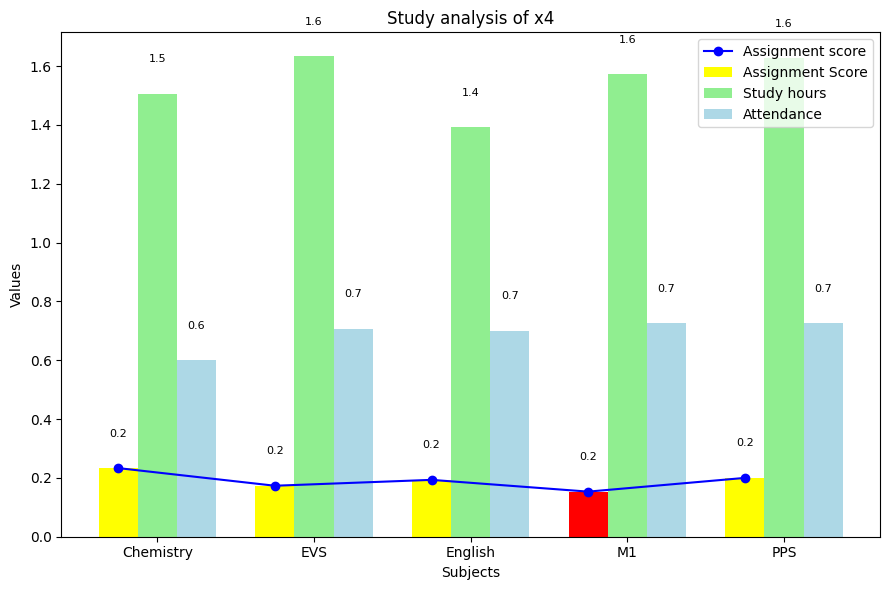

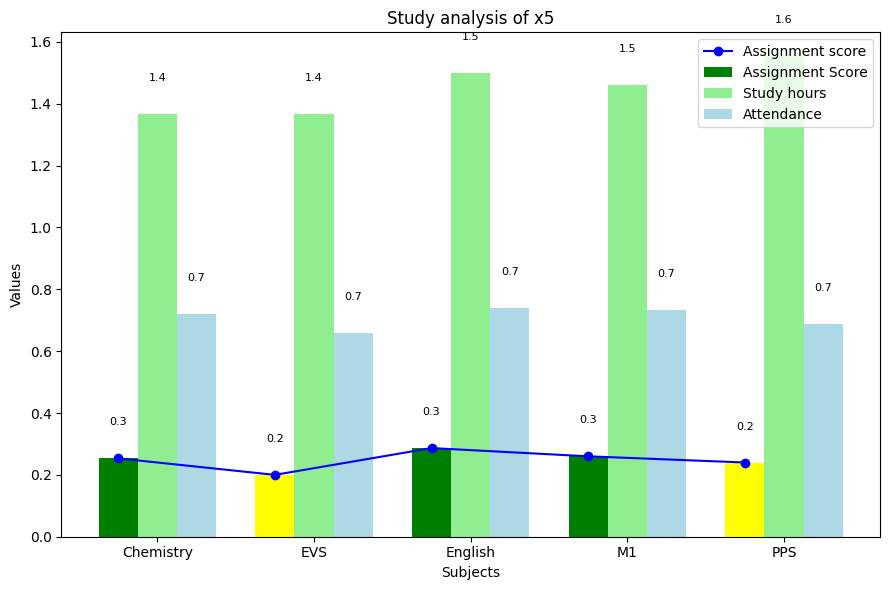

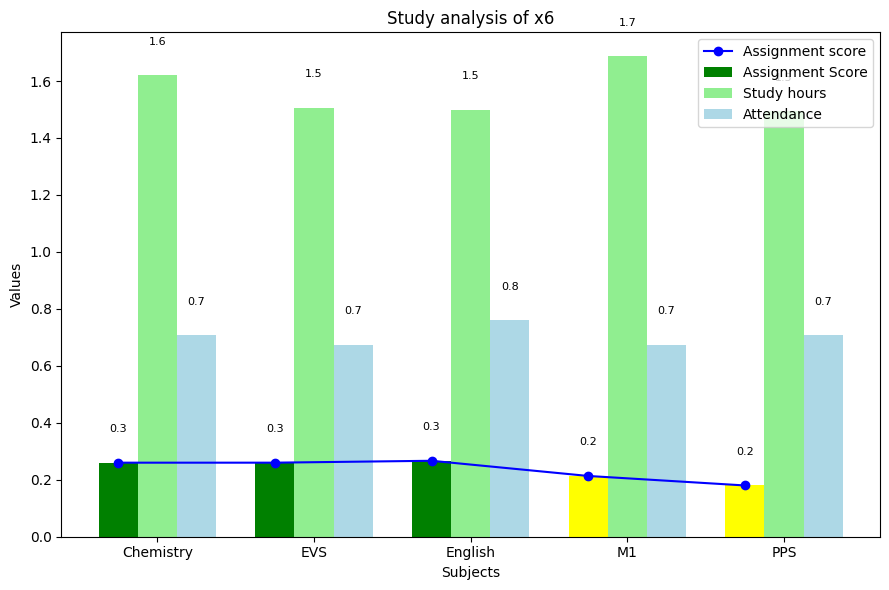

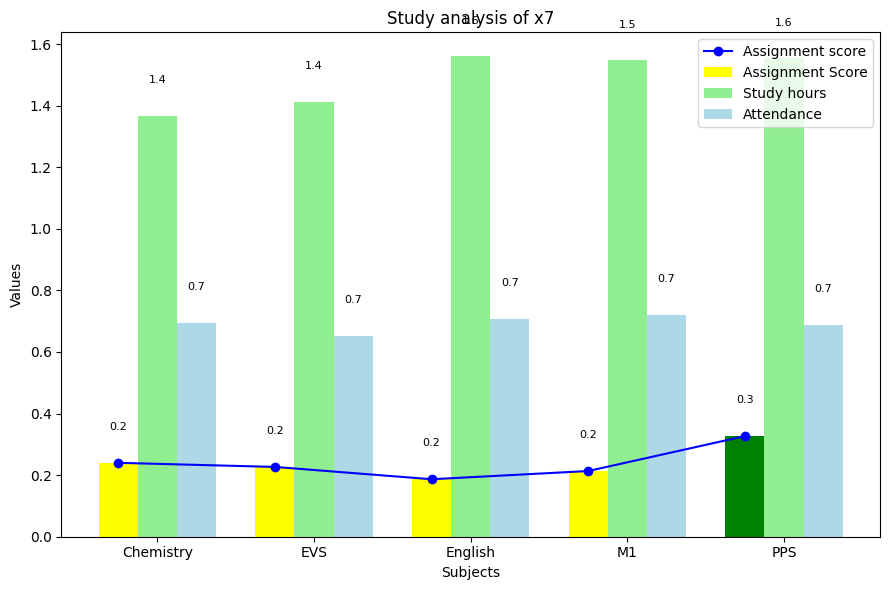

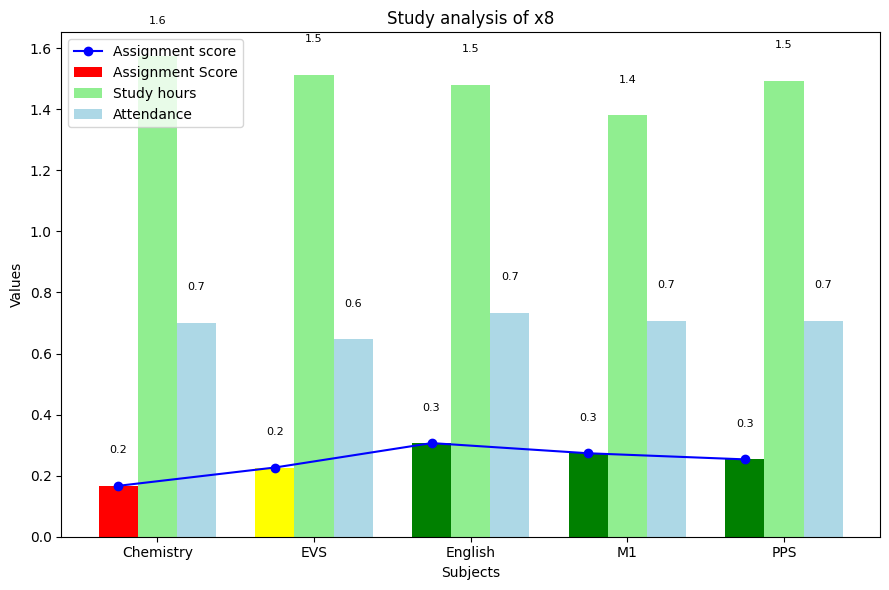

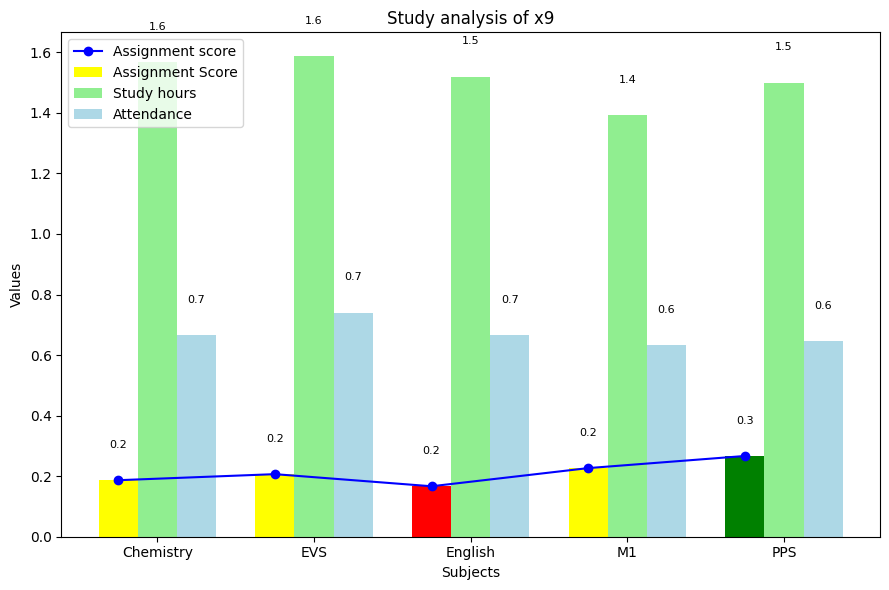

In [ ]:
students=final_data['sid'].unique()
for student in students:
  student_data=final_data[final_data['sid']== student]
  plt.figure(figsize=(9,6))
  colors=[]
  for marks in student_data['assignmet_marks']:
    if marks>= .25:
      colors.append('green')
    elif marks > .17:
      colors.append('yellow')
    else:
      colors.append('red')
  x=np.arange(len(student_data['subject']))
  bars1=plt.bar(x-0.25 , student_data['assignmet_marks'], color=colors,width=0.25, label='Assignment Score')
  bars2 = plt.bar(x,student_data['study_hours'], width=0.25, label='Study hours', color='lightgreen')
  bars3 = plt.bar(x+0.25, student_data['attendance'], width=0.25, label='Attendance', color='lightblue')
  plt.plot(x-0.25, student_data['assignmet_marks'], marker='o', linestyle='-', color='blue', label='Assignment score')

  for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{height:.1f}',
                 ha='center', va='bottom', fontsize=8)

  plt.xticks(x, student_data['subject'])
  plt.title(f'Study analysis of {student}')
  plt.xlabel('Subjects')
  plt.ylabel('Values')
  plt.tight_layout()
  # plt.ylim(0.00,0.35)
  plt.legend()
  plt.show()


In [ ]:
# prompt: Using dataframe final_data: how can i feed this data into to LinearRegression

from sklearn.linear_model import LinearRegression

# Prepare the data for Linear Regression
# Select the features (X) and the target variable (y)
# Assuming 'assignmet_marks' is the target variable
X = final_data[['study_hours', 'attendance']]  # Features
y = final_data['assignmet_marks']  # Target

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model to the data
model.fit(X, y)

# Now you can use the trained model to make predictions
# For example:
# new_data = pd.DataFrame({'study_hours': [1.5], 'attendance': [0.7]})
# predictions = model.predict(new_data)
# print(predictions)
